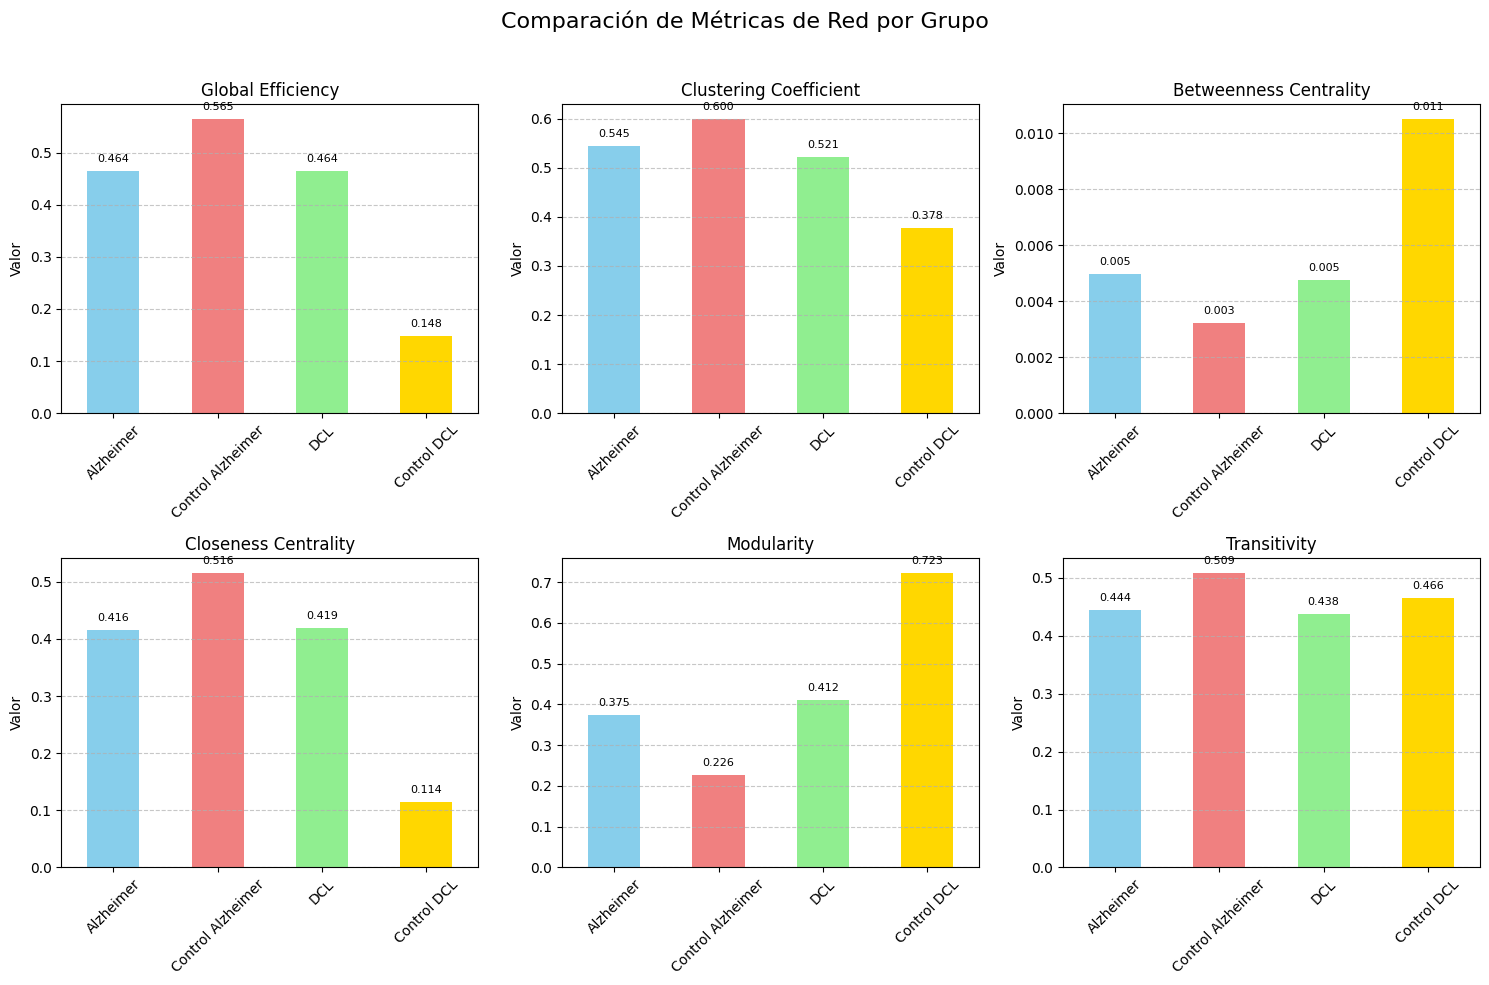

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Datos de la tabla proporcionados por el usuario
data = {
    'Group': ['Alzheimer', 'Control Alzheimer', 'DCL', 'Control DCL'],
    'Avg Path Length': [2.481115, np.nan, np.nan, np.nan],
    'Global Efficiency': [0.464101, 0.565277, 0.464267, 0.147878],
    'Avg Clustering Coefficient': [0.544511, 0.600349, 0.521481, 0.378294],
    'Avg Betweenness Centrality': [0.004970, 0.003223, 0.004777, 0.010528],
    'Avg Closeness Centrality': [0.415593, 0.515622, 0.419083, 0.114342],
    'Modularity': [0.375333, 0.226357, 0.411882, 0.723186],
    'Transitivity': [0.444053, 0.508734, 0.437961, 0.466057]
}

df = pd.DataFrame(data)
df = df.set_index('Group')

# 1. Eliminar la columna 'Avg Path Length' según la solicitud
df_plot = df.drop(columns=['Avg Path Length'])

# 2. Configurar el área de subplots
metrics = df_plot.columns
n_metrics = len(metrics)
n_rows = 2
n_cols = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()

# 3. Crear un gráfico de barras para cada métrica
for i, metric in enumerate(metrics):
    ax = axes[i]
    # Colores asignados a cada grupo
    colores = ['skyblue', 'lightcoral', 'lightgreen', 'gold']
    df_plot[metric].plot(kind='bar', ax=ax, color=colores)

    # Formato
    # Se elimina 'Avg ' del título del subplot
    ax.set_title(metric.replace('Avg ', ''), fontsize=12)
    ax.set_ylabel('Valor', fontsize=10)
    # Rotar etiquetas del eje X para mejor lectura
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_xlabel('') # Eliminar la etiqueta del índice ('Group') en los subplots

    # Añadir etiquetas de valor encima de las barras
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom',
                    fontsize=8, color='black',
                    xytext=(0, 5),
                    textcoords='offset points')

# 4. Ocultar subplots no utilizados
for i in range(n_metrics, n_rows * n_cols):
    fig.delaxes(axes[i])

# 5. Ajustar diseño y guardar
fig.suptitle('Comparación de Métricas de Red por Grupo', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('metricas_red_comparacion.png')

✅ Spider chart generado con escalado global para preservar proporciones reales.
Se ha generado un spider chart con el tamaño de letra ajustado y la leyenda reubicada.


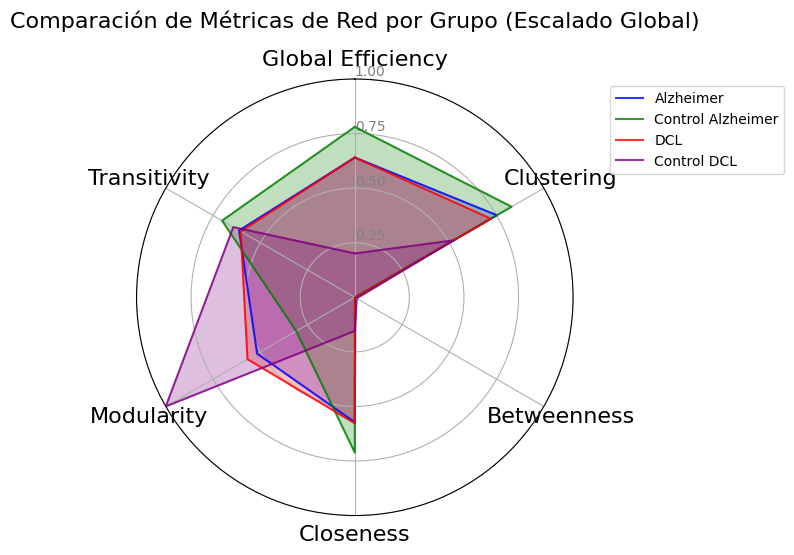

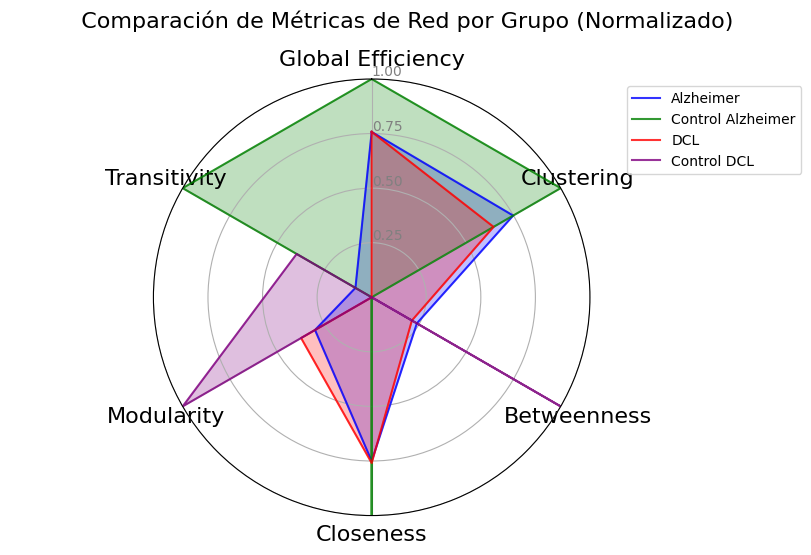

In [9]:

# Datos de la tabla proporcionados

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    'Group': ['Alzheimer', 'Control Alzheimer', 'DCL', 'Control DCL'],
    'Avg Path Length': [2.481115, np.nan, np.nan, np.nan],
    'Global Efficiency': [0.464101, 0.565277, 0.464267, 0.147878],
    'Avg Clustering Coefficient': [0.544511, 0.600349, 0.521481, 0.378294],
    'Avg Betweenness Centrality': [0.004970, 0.003223, 0.004777, 0.010528],
    'Avg Closeness Centrality': [0.415593, 0.515622, 0.419083, 0.114342],
    'Modularity': [0.375333, 0.226357, 0.411882, 0.723186],
    'Transitivity': [0.444053, 0.508734, 0.437961, 0.466057]
}

df = pd.DataFrame(data).set_index('Group')

# Eliminar 'Avg Path Length' si no se desea graficar
df_plot = df.drop(columns=['Avg Path Length'])

# Escalado opcional: normalizar todo el conjunto (no por columna)
min_val = df_plot.values.min()
max_val = df_plot.values.max()
df_scaled = (df_plot - min_val) / (max_val - min_val)

# Preparar etiquetas
labels = [col.replace('Avg ', '').replace(' Coefficient', '').replace(' Centrality', '') for col in df_plot.columns]
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]
labels += labels[:1]

# Crear gráfico
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['blue', 'green', 'red', 'purple']

for i, (group_name, row) in enumerate(df_scaled.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i], linewidth=1.5, label=group_name, alpha=0.8)
    ax.fill(angles, values, color=colors[i], alpha=0.25)

# Configuración estética
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels[:-1], fontsize=16)
ax.set_rlabel_position(0)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], color="grey", size=10)
ax.set_ylim(0, 1)

plt.title('Comparación de Métricas de Red por Grupo (Escalado Global)', size=16, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1))
plt.tight_layout()
plt.savefig('spider_chart_metricas_red_corregido.png')
print("✅ Spider chart generado con escalado global para preservar proporciones reales.")


df = pd.DataFrame(data)
df = df.set_index('Group')

# 1. Eliminar la columna 'Avg Path Length'
df_plot = df.drop(columns=['Avg Path Length'])

# 2. Normalizar los datos para el spider chart (escalar de 0 a 1)
df_normalized = df_plot.apply(lambda x: (x - x.min()) / (x.max() - x.min()))
df_normalized = df_normalized.fillna(0.5) # Rellenar NaN si hay columnas con un solo valor

# 3. Preparar los datos para el spider chart
labels = np.array(df_normalized.columns)
labels = [label.replace('Avg ', '').replace(' Coefficient', '').replace(' Centrality', '') for label in labels]
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]
labels += labels[:1]

# 4. Crear el spider chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['blue', 'green', 'red', 'purple']

for i, (group_name, row) in enumerate(df_normalized.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i], linewidth=1.5, linestyle='solid', label=group_name, alpha=0.8)
    ax.fill(angles, values, color=colors[i], alpha=0.25)

# 5. Configurar el gráfico con los ajustes solicitados
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles[:-1])
# Agrandar la letra de las etiquetas de las métricas (eje X)
ax.set_xticklabels(labels[:-1], fontsize=16) # Aumentado de 10 a 12

ax.set_rlabel_position(0)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
# Agrandar la letra de los valores del eje radial (eje Y)
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], color="grey", size=10) # Aumentado de 8 a 10
ax.set_ylim(0, 1)

# Agrandar la letra del título
plt.title('          Comparación de Métricas de Red por Grupo (Normalizado)', size=16, color='black', y=1.1) # Aumentado de 14 a 16
# Bajar un poco la leyenda
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1)) # 
plt.tight_layout()
plt.savefig('spider_chart_metricas_red_ajustado.png')
print("Se ha generado un spider chart con el tamaño de letra ajustado y la leyenda reubicada.")

Tomé las matrices de Alexa, les quité 1 col. Les pasé el código con las nuevas matrices cargadas en memoria

In [1]:
import pandas as pd
import numpy as np
import os

file_paths = {
    'Alzheimer': 'matrices_Maestria/AD_mean_correlation_matrix.csv',
    'Control Alzheimer': 'matrices_Maestria/CNAD_mean_correlation_matrix.csv',
    'DCL': 'matrices_Maestria/CNMCI_mean_correlation_matrix.csv',
    'Control DCL': 'matrices_Maestria/MCI_mean_correlation_matrix.csv'
}

corrected_matrices = {}

for name, path in file_paths.items():
    try:
        df = pd.read_csv(path, header=0)

        # Verificar si hay una columna de índice mal leída
        if df.shape[1] - df.shape[0] == 1:
            print(f"⚠️ '{name}' tiene una columna extra. Intentando eliminar la primera columna...")
            df = df.iloc[:, 1:]

        # Verificar si la matriz es cuadrada
        if df.shape[0] != df.shape[1]:
            print(f"❌ '{name}' sigue sin ser cuadrada: {df.shape}. Revisión manual recomendada.")
            continue

        corrected_matrices[name] = df.values
        print(f"✅ '{name}' corregida y cargada con forma {df.shape}")

    except FileNotFoundError:
        print(f"❌ Archivo no encontrado: {path}")
    except Exception as e:
        print(f"❌ Error al procesar '{name}': {e}")

# Ahora puedes usar corrected_matrices en tu análisis de grafos

⚠️ 'Alzheimer' tiene una columna extra. Intentando eliminar la primera columna...
✅ 'Alzheimer' corregida y cargada con forma (299, 299)
⚠️ 'Control Alzheimer' tiene una columna extra. Intentando eliminar la primera columna...
✅ 'Control Alzheimer' corregida y cargada con forma (299, 299)
⚠️ 'DCL' tiene una columna extra. Intentando eliminar la primera columna...
✅ 'DCL' corregida y cargada con forma (299, 299)
⚠️ 'Control DCL' tiene una columna extra. Intentando eliminar la primera columna...
✅ 'Control DCL' corregida y cargada con forma (299, 299)


In [5]:
import networkx as nx

metrics_to_plot = {
    'Avg Path Length': [],
    'Global Efficiency': [],
    'Avg Clustering Coefficient': [],
    'Avg Betweenness Centrality': [],
    'Avg Closeness Centrality': [],
    'Modularity': [],
    'Transitivity': []
}

group_names = list(corrected_matrices.keys())
#threshold = 0.5 # DEFINIR VALOR
threshold = np.percentile([m for m in corrected_matrices.values()], 90) #binarization, e.g., keep the top 10% of connections

for group_name, matrix in corrected_matrices.items():
    adj_matrix = (np.abs(matrix) > threshold).astype(int)
    G = nx.from_numpy_array(adj_matrix)
    G.remove_edges_from(nx.selfloop_edges(G))

    # Calcular metricas
    if nx.is_connected(G):
        avg_path_length = nx.average_shortest_path_length(G)
    else:
        avg_path_length = np.nan # NaN para grafos no conectados
        
    global_efficiency = nx.global_efficiency(G)
    avg_clustering_coefficient = nx.average_clustering(G)
    avg_betweenness = np.mean(list(nx.betweenness_centrality(G).values()))
    avg_closeness = np.mean(list(nx.closeness_centrality(G).values()))

    try:
        communities = nx.community.greedy_modularity_communities(G)
        modularity = nx.community.modularity(G, communities)
    except:
        modularity = np.nan

    transitivity = nx.transitivity(G)

    # Guardar cada métrica
    metrics_to_plot['Avg Path Length'].append(avg_path_length)
    metrics_to_plot['Global Efficiency'].append(global_efficiency)
    metrics_to_plot['Avg Clustering Coefficient'].append(avg_clustering_coefficient)
    metrics_to_plot['Avg Betweenness Centrality'].append(avg_betweenness)
    metrics_to_plot['Avg Closeness Centrality'].append(avg_closeness)
    metrics_to_plot['Modularity'].append(modularity)
    metrics_to_plot['Transitivity'].append(transitivity)

# CDataFrame 
df_metrics = pd.DataFrame(metrics_to_plot, index=group_names)
print(df_metrics)

                   Avg Path Length  Global Efficiency  \
Alzheimer                 1.986353           0.556269   
Control Alzheimer         1.930237           0.569624   
DCL                       1.911742           0.574789   
Control DCL               1.879419           0.584321   

                   Avg Clustering Coefficient  Avg Betweenness Centrality  \
Alzheimer                            0.468140                    0.003321   
Control Alzheimer                    0.474206                    0.003132   
DCL                                  0.465294                    0.003070   
Control DCL                          0.466050                    0.002961   

                   Avg Closeness Centrality  Modularity  Transitivity  
Alzheimer                          0.508437    0.276106      0.443339  
Control Alzheimer                  0.522328    0.276888      0.447324  
DCL                                0.527083    0.260578      0.445106  
Control DCL                        0.535

Ahora creamos el Spider con esas metricas de la matriz de Alexa

✅ Spider chart generado con escalado global para preservar proporciones reales.


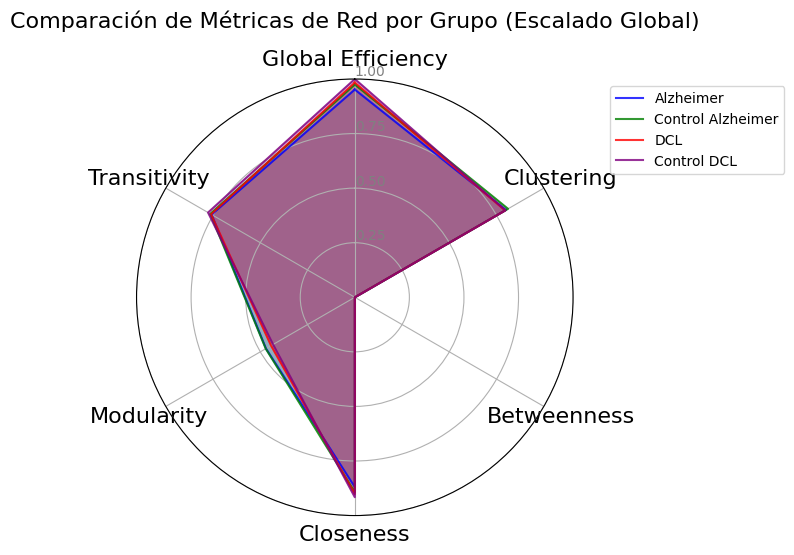

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Datos originales
data = {
    'Group': ['Alzheimer', 'Control Alzheimer', 'DCL', 'Control DCL'],
    'Avg Path Length': [1.986353, 1.930237, 1.911742, 1.879419],
    'Global Efficiency': [0.556269, 0.569624, 0.574789, 0.584321],
    'Avg Clustering Coefficient': [0.468140, 0.474206, 0.465294, 0.466050],
    'Avg Betweenness Centrality': [0.003321, 0.003132, 0.003070, 0.002961],
    'Avg Closeness Centrality': [0.508437, 0.522328, 0.527083, 0.535487],
    'Modularity': [0.276106, 0.276888, 0.260578, 0.254394],
    'Transitivity': [0.443339, 0.447324, 0.445106, 0.454366]
}

df = pd.DataFrame(data).set_index('Group')

# Eliminar 'Avg Path Length' si no se desea graficar
df_plot = df.drop(columns=['Avg Path Length'])

# Escalado opcional: normalizar todo el conjunto (no por columna)
min_val = df_plot.values.min()
max_val = df_plot.values.max()
df_scaled = (df_plot - min_val) / (max_val - min_val)

# Preparar etiquetas
labels = [col.replace('Avg ', '').replace(' Coefficient', '').replace(' Centrality', '') for col in df_plot.columns]
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]
labels += labels[:1]

# Crear gráfico
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['blue', 'green', 'red', 'purple']

for i, (group_name, row) in enumerate(df_scaled.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i], linewidth=1.5, label=group_name, alpha=0.8)
    ax.fill(angles, values, color=colors[i], alpha=0.25)

# Configuración estética
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels[:-1], fontsize=16)
ax.set_rlabel_position(0)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], color="grey", size=10)
ax.set_ylim(0, 1)

plt.title('Comparación de Métricas de Red por Grupo (Escalado Global)', size=16, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1))
plt.tight_layout()
plt.savefig('spider_chart_metricas_red_corregido.png')
print("✅ Spider chart generado con escalado global para preservar proporciones reales.")

Este es el código general que crea el df de metricas

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx

file_paths = {
    'Alzheimer': 'matrices_Maestria/AD_mean_correlation_matrix.csv',
    'Control Alzheimer': 'matrices_Maestria/CNAD_mean_correlation_matrix.csv',
    'DCL': 'matrices_Maestria/CNMCI_mean_correlation_matrix.csv',
    'Control DCL': 'matrices_Maestria/MCI_mean_correlation_matrix.csv'
}

try:
    correlation_matrices = {name: pd.read_csv(path, header=0).values for name, path in file_paths.items()}
    print("✅ Matrices loaded successfully from CSV files.")
except FileNotFoundError as e:
    print(f"❌ Error: Could not find the file {e.filename}.")
    exit()

# Definir metricas a plotear
metrics_to_plot = {
    'Avg Path Length': [],
    'Global Efficiency': [],
    'Avg Clustering Coefficient': [],
    'Avg Betweenness Centrality': [],
    'Avg Closeness Centrality': [],
    'Modularity': [],
    'Transitivity': []
}

group_names = list(correlation_matrices.keys())
#threshold = 0.5 # DEFINIR VALOR
threshold = np.percentile([m for m in correlation_matrices.values()], 90) #binarization, e.g., keep the top 10% of connections
for group_name, matrix in correlation_matrices.items():
    adj_matrix = (np.abs(matrix) > threshold).astype(int)
    G = nx.from_numpy_array(adj_matrix)
    G.remove_edges_from(nx.selfloop_edges(G))

    # Calcular metricas
    if nx.is_connected(G):
        avg_path_length = nx.average_shortest_path_length(G)
    else:
        avg_path_length = np.nan # NaN para grafos no conectados
        
    global_efficiency = nx.global_efficiency(G)
    avg_clustering_coefficient = nx.average_clustering(G)
    avg_betweenness = np.mean(list(nx.betweenness_centrality(G).values()))
    avg_closeness = np.mean(list(nx.closeness_centrality(G).values()))

    try:
        communities = nx.community.greedy_modularity_communities(G)
        modularity = nx.community.modularity(G, communities)
    except:
        modularity = np.nan

    transitivity = nx.transitivity(G)

    # Guardar cada métrica
    metrics_to_plot['Avg Path Length'].append(avg_path_length)
    metrics_to_plot['Global Efficiency'].append(global_efficiency)
    metrics_to_plot['Avg Clustering Coefficient'].append(avg_clustering_coefficient)
    metrics_to_plot['Avg Betweenness Centrality'].append(avg_betweenness)
    metrics_to_plot['Avg Closeness Centrality'].append(avg_closeness)
    metrics_to_plot['Modularity'].append(modularity)
    metrics_to_plot['Transitivity'].append(transitivity)

# CDataFrame 
df_metrics = pd.DataFrame(metrics_to_plot, index=group_names)
print(df_metrics)

✅ Matrices loaded successfully from CSV files.


NetworkXError: Adjacency matrix not square: nx,ny=(299, 300)